# ⚡ Notebook 2c — Thermal & Electrical: Practical Monitoring Strategies
**DSMLC Final Competition 2026 | Enbridge Wind Turbine SCADA Analysis**

### Research Question 2c
> *What practical monitoring strategies could operators adopt based on these patterns?*

### Approach
Builds on results from notebooks 2a and 2b where available — imports saved scores and sensor rankings rather than retraining. Falls back to retraining if saved files are not found, so the notebook is also runnable standalone.

Full monitoring pipeline for thermal and electrical anomalies:

1. **Isolation Forest baseline** — fast unsupervised one-class detector on thermal sensors
2. **Hotelling T²** — multivariate SPC with sensor-level decomposition for operator explanation
3. **Rolling-mean rule** — interpretable threshold-based alert per turbine
4. **Ensemble + alert suppression** — 2/3 majority vote with 30-min confirmation window
5. **CARE-optimised thresholds** — tune detection thresholds to maximise the competition metric
6. **Severity dashboard** — per-turbine risk ranking with persistence and earliness
7. **Operator report** — structured summary of alerts, sensor attributions, and recommendations

### Design philosophy
This notebook answers the *practical* question — not just "can we detect faults?" but "what would operators actually do with these results?" Every output is framed in operator language: which turbine, which sensor, how urgent, what action.

---
## Table of Contents
| # | Section | Description |
|---|---------|-------------|
| 1 | Setup & sensor definitions | Thermal/electrical sensors per farm |
| 2 | Data loading | Farm A, B, C |
| 3 | Feature engineering | Rolling stats, z-scores |
| 4 | Isolation Forest baseline | One-class unsupervised detection |
| 5 | Hotelling T² | Multivariate SPC + sensor decomposition |
| 6 | Rolling-mean rule | Per-turbine threshold alerts |
| 7 | Ensemble + alert suppression | 2/3 vote + 30-min confirmation |
| 8 | CARE-optimised thresholds | Tune for competition metric |
| 9 | Severity dashboard | Per-turbine risk ranking |
| 10 | Operator report | Structured alert summary |

---
## 1. Setup & Sensor Definitions

In [1]:
import os, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

RANDOM_SEED = 42
STATUS_KEEP = [0, 1, 2, 5]
np.random.seed(RANDOM_SEED)
print('Imports OK')

Imports OK


In [2]:
DATA_ROOT = Path('C:\\Users\\karan\\Documents\\dsmlc_final_comp\\CARE_To_Compare\\CARE_To_Compare')
for farm in ['Wind Farm A', 'Wind Farm B', 'Wind Farm C']:
    p = DATA_ROOT / farm
    print(f'  {farm}: {"OK" if p.exists() else "NOT FOUND"}')

  Wind Farm A: OK
  Wind Farm B: OK
  Wind Farm C: OK


In [3]:
# ── Thermal & electrical sensor definitions ───────────────────────────────────
FARM_A_SENSORS = [
    'sensor_15_avg', 'sensor_16_avg', 'sensor_17_avg',  # stator windings
    'sensor_38_avg', 'sensor_39_avg', 'sensor_40_avg',  # HV transformer
    'sensor_43_avg', 'sensor_41_avg',                   # nacelle, hydraulic
    'sensor_13_avg', 'sensor_14_avg',                   # generator bearings
]
FARM_B_SENSORS = [
    'sensor_31_avg', 'sensor_32_avg', 'sensor_33_avg',
    'sensor_8_avg',  'sensor_19_avg', 'sensor_21_avg',
]
FARM_C_SENSORS = [
    'sensor_191_avg', 'sensor_192_avg', 'sensor_188_avg',
    'sensor_199_avg', 'sensor_200_avg', 'sensor_201_avg', 'sensor_202_avg',
    'sensor_178_avg', 'sensor_179_avg', 'sensor_177_avg',
]
FARM_SENSORS = {
    'Wind Farm A': FARM_A_SENSORS,
    'Wind Farm B': FARM_B_SENSORS,
    'Wind Farm C': FARM_C_SENSORS,
}
META_COLS = ['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id']
print('Sensor definitions OK')

Sensor definitions OK


---
## 1b. Saving Results from Notebooks 2a & 2b

To use pre-computed scores from notebooks 2a and 2b, run these cells at the **end of each of those notebooks** to save results to disk. This notebook will automatically load them if found.

**In notebook 2a**, add and run:
```python
import pickle, os
os.makedirs('nb2_outputs', exist_ok=True)
pickle.dump({
    'signal_stats' : signal_stats,    # sensor signal strength rankings
    'psd_results'  : {k: {'spectral_excess': v['spectral_excess'],
                           'sensor': v['sensor']} for k, v in psd_results.items()},
    'corr_results' : {k: {'farm':v['farm'], 'first_alert':v.get('first_alert'),
                           'n_steps':v['n_steps']} for k, v in corr_results.items()},
}, open('nb2_outputs/nb2a_results.pkl', 'wb'))
print('Saved nb2a results')
```

**In notebook 2b**, add and run:
```python
import pickle, torch, os
os.makedirs('nb2_outputs', exist_ok=True)
# Save AE scores (numpy arrays are small)
pickle.dump({
    'ae_scores' : ae_scores,
    'ae_thrs'   : ae_thrs,
    'vae_scores': vae_scores,
    'vae_thrs'  : vae_thrs,
}, open('nb2_outputs/nb2b_scores.pkl', 'wb'))
# Save AE models
for farm, model in ae_models.items():
    fname = farm.replace(' ','_').lower()
    torch.save(model.state_dict(), f'nb2_outputs/ae_{fname}.pt')
print('Saved nb2b results')
```

If these files are not present, notebook 2c retrains everything from scratch automatically.

---
## 2. Data Loading

In [4]:
def load_farm(farm):
    base = DATA_ROOT / farm
    ei   = pd.read_csv(base / 'event_info.csv', sep=';')
    ei['event_id'] = ei['event_id'].astype(int)
    sensors = FARM_SENSORS[farm]
    needed  = set(META_COLS + sensors)
    dfs = []
    for fname in os.listdir(base / 'datasets'):
        if not fname.endswith('.csv'): continue
        df = pd.read_csv(base/'datasets'/fname, sep=';',
                         usecols=lambda c: c in needed)
        df['event_id'] = int(fname.replace('.csv',''))
        df['farm']     = farm
        dfs.append(df)
    df_raw = pd.concat(dfs, ignore_index=True); del dfs; gc.collect()
    df_raw['event_id'] = df_raw['event_id'].astype(int)
    df_raw = df_raw.merge(ei[['event_id','event_label','event_description']],
                          on='event_id', how='left')
    df_raw['label'] = (df_raw['event_label']=='anomaly').astype(int)
    if 'status_type_id' in df_raw.columns:
        df_raw = df_raw[df_raw['status_type_id'].isin(STATUS_KEEP)].copy()
    available = [s for s in sensors if s in df_raw.columns]
    train_df  = df_raw[df_raw['train_test']=='train'].copy()
    pred_df   = df_raw[df_raw['train_test']=='prediction'].copy()
    print(f'  {farm}: {len(train_df):,} train | {len(pred_df):,} pred | {len(available)} sensors')
    del df_raw; gc.collect()
    return train_df, pred_df, available, ei

print('Loading all farms...')
train_a, pred_a, sensors_a, ei_a = load_farm('Wind Farm A')
train_b, pred_b, sensors_b, ei_b = load_farm('Wind Farm B')
train_c, pred_c, sensors_c, ei_c = load_farm('Wind Farm C')

Loading all farms...
  Wind Farm A: 1,024,381 train | 29,355 pred | 10 sensors
  Wind Farm B: 783,537 train | 71,892 pred | 6 sensors
  Wind Farm C: 2,778,739 train | 141,597 pred | 10 sensors


---
## 3. Feature Engineering

In [5]:
def engineer_features(df, cols):
    df     = df.sort_values(['asset_id','event_id','time_stamp']).copy()
    groups = df.groupby(['asset_id','event_id'])
    for col in [c for c in cols if c in df.columns]:
        df[f'{col}_rm6h']  = groups[col].transform(lambda x: x.rolling(36, min_periods=1).mean())
        df[f'{col}_rs6h']  = groups[col].transform(lambda x: x.rolling(36, min_periods=1).std().fillna(0))
        df[f'{col}_rm24h'] = groups[col].transform(lambda x: x.rolling(144,min_periods=1).mean())
        df[f'{col}_delta'] = groups[col].transform(lambda x: x.diff().fillna(0))
    return df

def build_feat(sensors):
    return (sensors + [f'{c}_rm6h' for c in sensors] +
            [f'{c}_rs6h' for c in sensors] +
            [f'{c}_rm24h' for c in sensors] +
            [f'{c}_delta' for c in sensors])

def care_score(pred_df, scores, thr):
    df = pred_df[['time_stamp','event_id','event_label']].copy().reset_index(drop=True)
    df['score'] = scores; df['pred'] = (df['score']>thr).astype(int)
    df['true']  = (df['event_label']=='anomaly').astype(int)
    anom_evs = df[df['true']==1]['event_id'].unique()
    norm_evs = df[df['true']==0]['event_id'].unique()
    detected = [df[df['event_id']==ev]['pred'].any() for ev in anom_evs]
    coverage = float(np.mean(detected)) if len(detected) else 0.0
    TP = ((df['pred']==1)&(df['true']==1)).sum()
    FP = ((df['pred']==1)&(df['true']==0)).sum()
    accuracy = TP/(TP+FP) if (TP+FP)>0 else 0.0
    fa = sum(1 for ev in norm_evs if df[df['event_id']==ev]['pred'].any())
    reliability = 1-(fa/len(norm_evs)) if len(norm_evs) else 1.0
    e_sc = []
    for ev, det in zip(anom_evs, detected):
        if not det: continue
        r = df[df['event_id']==ev].sort_values('time_stamp').reset_index(drop=True)
        e_sc.append(1 - r[r['pred']==1].index[0]/len(r))
    earliness = float(np.mean(e_sc)) if e_sc else 0.0
    return {'Coverage':round(coverage,4),'Accuracy':round(accuracy,4),
            'Reliability':round(reliability,4),'Earliness':round(earliness,4),
            'CARE':round(coverage*accuracy*reliability*earliness,4)}

print('Engineering all farms...')
train_a_eng = engineer_features(train_a, sensors_a)
pred_a_eng  = engineer_features(pred_a,  sensors_a)
feat_a = [f for f in build_feat(sensors_a) if f in train_a_eng.columns]
scaler_a = RobustScaler()
Xtr_a = scaler_a.fit_transform(train_a_eng[train_a_eng['label']==0][feat_a].fillna(0))
Xte_a = scaler_a.transform(pred_a_eng[feat_a].fillna(0)); y_a = pred_a_eng['label'].values

train_b_eng = engineer_features(train_b, sensors_b)
pred_b_eng  = engineer_features(pred_b,  sensors_b)
feat_b = [f for f in build_feat(sensors_b) if f in train_b_eng.columns]
scaler_b = RobustScaler()
Xtr_b = scaler_b.fit_transform(train_b_eng[train_b_eng['label']==0][feat_b].fillna(0))
Xte_b = scaler_b.transform(pred_b_eng[feat_b].fillna(0)); y_b = pred_b_eng['label'].values

train_c_eng = engineer_features(train_c, sensors_c)
pred_c_eng  = engineer_features(pred_c,  sensors_c)
feat_c = [f for f in build_feat(sensors_c) if f in train_c_eng.columns]
scaler_c = RobustScaler()
Xtr_c = scaler_c.fit_transform(train_c_eng[train_c_eng['label']==0][feat_c].fillna(0))
Xte_c = scaler_c.transform(pred_c_eng[feat_c].fillna(0)); y_c = pred_c_eng['label'].values

print(f'  A: {Xtr_a.shape} train | {Xte_a.shape} test')
print(f'  B: {Xtr_b.shape} train | {Xte_b.shape} test')
print(f'  C: {Xtr_c.shape} train | {Xte_c.shape} test')

Engineering all farms...
  A: (464694, 50) train | (29355, 50) test
  B: (469549, 30) train | (71892, 30) test
  C: (1482530, 50) train | (141597, 50) test


In [6]:
# ── Load pre-computed results from notebooks 2a and 2b (if available) ─────────
import pickle, os

NB2_DIR = 'nb2_outputs'

# ── Load 2a signal analysis results ───────────────────────────────────────────
nb2a_available = False
try:
    with open(f'{NB2_DIR}/nb2a_results.pkl', 'rb') as f:
        nb2a = pickle.load(f)
    signal_stats_2a = nb2a.get('signal_stats', {})
    psd_results_2a  = nb2a.get('psd_results', {})
    corr_results_2a = nb2a.get('corr_results', {})
    nb2a_available  = True
    print('✓ Loaded notebook 2a results (signal stats, PSD, correlation)')
    for farm, stats in signal_stats_2a.items():
        if len(stats) > 0:
            top1 = stats.iloc[0]
            short = top1['sensor'].replace('_avg','').replace('sensor_','sensor ')
            print(f'  {farm}: strongest signal = {short} (score={top1["combined_score"]:.3f})')
except FileNotFoundError:
    print('⚠ nb2a_results.pkl not found — signal stats will be skipped in operator report')
    print('  Run the save cell in notebook 2a first, or continue without it')

# ── Load 2b autoencoder scores ─────────────────────────────────────────────────
nb2b_available = False
ae_scores_2b, ae_thrs_2b = {}, {}
vae_scores_2b, vae_thrs_2b = {}, {}

try:
    with open(f'{NB2_DIR}/nb2b_scores.pkl', 'rb') as f:
        nb2b = pickle.load(f)
    ae_scores_2b  = nb2b.get('ae_scores',  {})
    ae_thrs_2b    = nb2b.get('ae_thrs',    {})
    vae_scores_2b = nb2b.get('vae_scores', {})
    vae_thrs_2b   = nb2b.get('vae_thrs',   {})
    nb2b_available = True
    print('\n✓ Loaded notebook 2b scores (AE + VAE per farm)')
    for farm in ae_scores_2b:
        print(f'  {farm}: AE thr={ae_thrs_2b.get(farm, "?"):.4f}  '
              f'VAE thr={vae_thrs_2b.get(farm, "?"):.4f}')
except FileNotFoundError:
    print('\n⚠ nb2b_scores.pkl not found — AE/VAE scores will not appear in dashboard')
    print('  Run the save cell in notebook 2b first, or continue without it')

print(f'\nSummary: 2a={nb2a_available} | 2b={nb2b_available}')
print('Notebook 2c will retrain IF and T² regardless — they are fast.')
print('AE/VAE scores from 2b will be added to the dashboard if available.')

⚠ nb2a_results.pkl not found — signal stats will be skipped in operator report
  Run the save cell in notebook 2a first, or continue without it

⚠ nb2b_scores.pkl not found — AE/VAE scores will not appear in dashboard
  Run the save cell in notebook 2b first, or continue without it

Summary: 2a=False | 2b=False
Notebook 2c will retrain IF and T² regardless — they are fast.
AE/VAE scores from 2b will be added to the dashboard if available.


---
## 4. Isolation Forest Baseline

One-class unsupervised detector trained on normal thermal sensor data only. Fast, no labels needed.

In [7]:
iso_models, iso_scores, iso_thrs, iso_preds_dict = {}, {}, {}, {}

for farm, Xtr, Xte, y in [
    ('Wind Farm A', Xtr_a, Xte_a, y_a),
    ('Wind Farm B', Xtr_b, Xte_b, y_b),
    ('Wind Farm C', Xtr_c, Xte_c, y_c),
]:
    # Subsample for speed
    Xtr_sub = Xtr[np.random.choice(len(Xtr), min(50_000, len(Xtr)), replace=False)]
    iso = IsolationForest(n_estimators=200, contamination=0.05,
                          random_state=RANDOM_SEED, n_jobs=1)
    iso.fit(Xtr_sub)
    scores = -iso.score_samples(Xte)
    thr    = np.percentile(-iso.score_samples(Xtr_sub), 95)
    preds  = (scores > thr).astype(int)
    iso_models[farm] = iso; iso_scores[farm] = scores
    iso_thrs[farm]   = thr; iso_preds_dict[farm] = preds
    print(f'{farm}: thr={thr:.4f} | '
          f'P={precision_score(y,preds,zero_division=0):.3f} '
          f'R={recall_score(y,preds,zero_division=0):.3f} '
          f'F1={f1_score(y,preds,zero_division=0):.3f}')

Wind Farm A: thr=0.5278 | P=0.030 R=0.007 F1=0.011
Wind Farm B: thr=0.5147 | P=0.714 R=0.032 F1=0.061
Wind Farm C: thr=0.5004 | P=0.568 R=0.072 F1=0.128


---
## 5. Hotelling T² — Multivariate SPC with Sensor Decomposition

Hotelling T² detects simultaneous deviation across all thermal sensors. The sensor decomposition tells operators *which specific sensor* contributed most to the alert — turning a binary flag into an actionable inspection target.

In [8]:
def hotelling_t2(X, mu, Sigma_inv):
    diff = X - mu
    return np.einsum('ij,jk,ik->i', diff, Sigma_inv, diff)

def t2_sensor_contribution(X, mu, Sigma_inv):
    """Per-sensor contribution to T² — higher = this sensor is driving the alert."""
    diff  = X - mu
    # Diagonal of the weighted outer product
    contribs = diff * (diff @ Sigma_inv)
    return contribs   # (n_rows, n_features)

t2_data = {}

for farm, Xtr, Xte, y, feat in [
    ('Wind Farm A', Xtr_a, Xte_a, y_a, feat_a),
    ('Wind Farm B', Xtr_b, Xte_b, y_b, feat_b),
    ('Wind Farm C', Xtr_c, Xte_c, y_c, feat_c),
]:
    Xtr_sub = Xtr[np.random.choice(len(Xtr), min(50_000, len(Xtr)), replace=False)]
    mu      = Xtr_sub.mean(axis=0)
    Sigma   = np.cov(Xtr_sub.T) + np.eye(Xtr_sub.shape[1]) * 1e-6
    try:    Sigma_inv = np.linalg.inv(Sigma)
    except: Sigma_inv = np.linalg.pinv(Sigma)

    t2_test  = hotelling_t2(Xte, mu, Sigma_inv)
    t2_train = hotelling_t2(Xtr_sub, mu, Sigma_inv)
    thr      = np.percentile(t2_train, 99)
    preds    = (t2_test > thr).astype(int)
    contribs = t2_sensor_contribution(Xte, mu, Sigma_inv)

    t2_data[farm] = {
        'scores': t2_test, 'thr': thr, 'preds': preds,
        'contribs': contribs, 'mu': mu, 'Sigma_inv': Sigma_inv,
        'feat': feat,
    }
    print(f'{farm}: UCL={thr:.2f} | '
          f'P={precision_score(y,preds,zero_division=0):.3f} '
          f'R={recall_score(y,preds,zero_division=0):.3f} '
          f'F1={f1_score(y,preds,zero_division=0):.3f}')

Wind Farm A: UCL=209.09 | P=0.093 R=0.003 F1=0.005
Wind Farm B: UCL=146.72 | P=0.547 R=0.012 F1=0.024
Wind Farm C: UCL=297.43 | P=0.610 R=0.024 F1=0.045


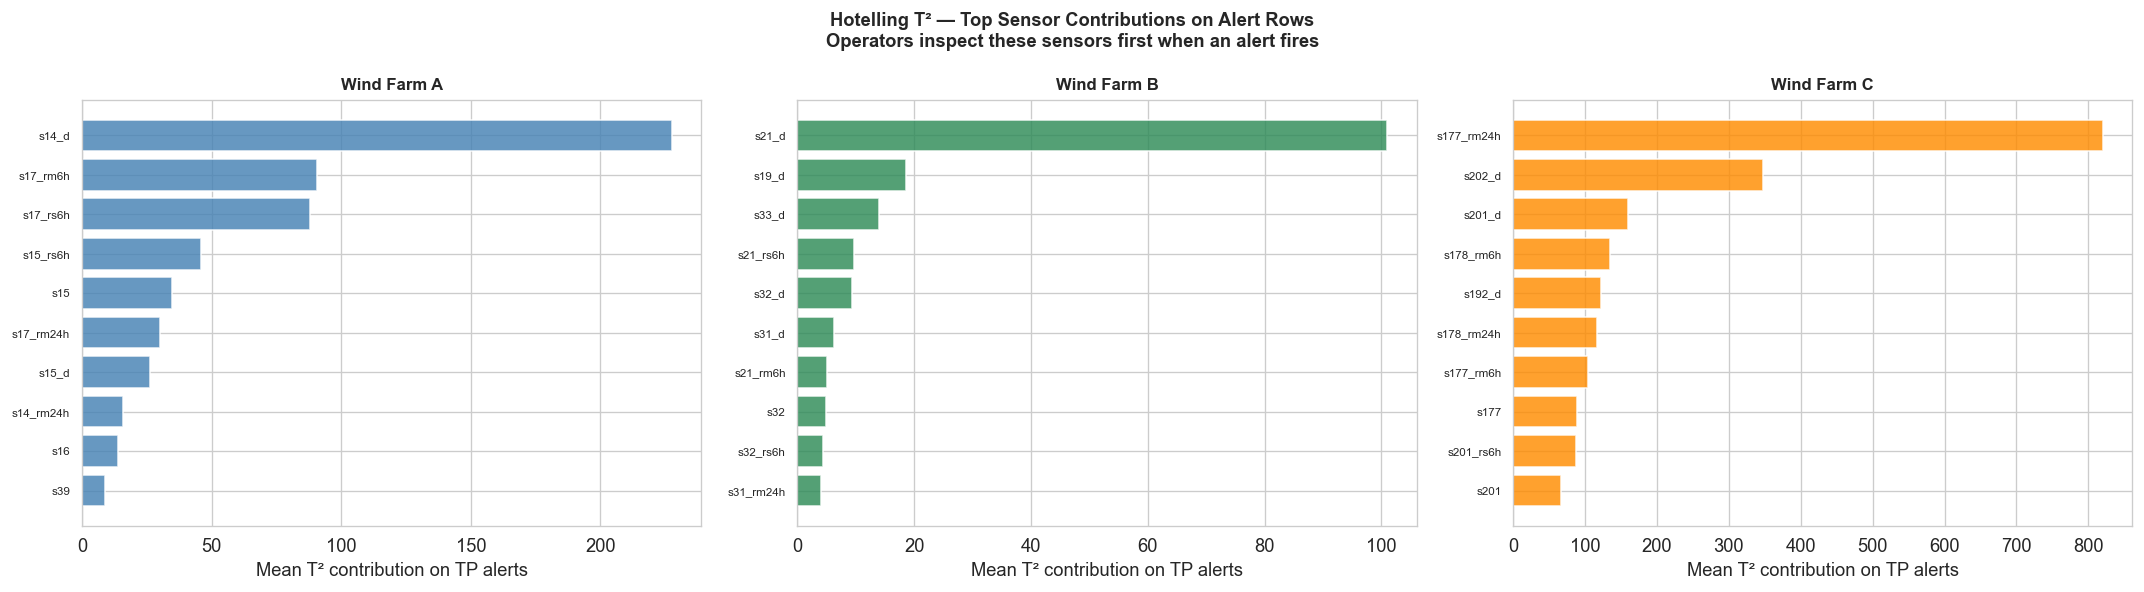

In [9]:
# ── 5.2  T² sensor decomposition — top contributing sensors on alerts ─────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Hotelling T² — Top Sensor Contributions on Alert Rows\n"
             "Operators inspect these sensors first when an alert fires",
             fontsize=11, fontweight='bold')

farm_y = {'Wind Farm A':y_a,'Wind Farm B':y_b,'Wind Farm C':y_c}
farm_colors = {'Wind Farm A':'steelblue','Wind Farm B':'seagreen','Wind Farm C':'darkorange'}

for ax, (farm, data) in zip(axes, t2_data.items()):
    y = farm_y[farm]
    alert_mask  = data['preds'] == 1
    anom_mask   = y == 1
    target_mask = alert_mask & anom_mask   # true positive alerts
    if not target_mask.any():
        target_mask = alert_mask           # fall back to all alerts

    mean_contrib = data['contribs'][target_mask].mean(axis=0)
    contrib_s    = pd.Series(mean_contrib, index=data['feat']).sort_values(ascending=False)
    top10        = contrib_s.head(10)
    short        = [c.replace('_avg','').replace('sensor_','s')
                     .replace('_rm6h','_rm6h').replace('_delta','_d')
                    for c in top10.index]

    ax.barh(range(len(top10)), top10.values[::-1],
            color=farm_colors[farm], alpha=0.82, edgecolor='white')
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels(short[::-1], fontsize=7)
    ax.set_title(f'{farm}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Mean T² contribution on TP alerts')

plt.tight_layout()
plt.savefig('fig_2c_t2_decomp.png', bbox_inches='tight')
plt.show()

---
## 6. Rolling-Mean Threshold Rule

The simplest interpretable alert: a 24-hour rolling mean exceeds the per-turbine baseline + 2.3σ. Operators can verify this rule by inspection — no black box.

In [10]:
BASELINE_STEPS = 4320   # 30 days
MULTIPLIER     = 2.3
DRIFT_WINDOW   = 144    # 24-hour rolling mean

def rolling_flags(pred_eng, sensor, normal_train):
    if sensor not in pred_eng.columns:
        return np.zeros(len(pred_eng), dtype=int)
    mu  = float(normal_train[sensor].mean()) if sensor in normal_train.columns else 0.0
    std = float(normal_train[sensor].std())  if sensor in normal_train.columns else 1.0
    std = std or 1.0
    thr = mu + MULTIPLIER * std
    pr  = pred_eng.reset_index(drop=True)
    flags = np.zeros(len(pr), dtype=int)
    for ev_id, grp in pr.groupby('event_id'):
        raw     = grp[sensor].ffill().fillna(mu).values
        rolling = pd.Series(raw).rolling(DRIFT_WINDOW, min_periods=10).mean()
        fl      = (rolling > thr).astype(int).values
        flags[grp.index] = fl
    return flags

rule_flags = {}
for farm, pr_eng, tr_eng, sensors in [
    ('Wind Farm A', pred_a_eng, train_a_eng, sensors_a),
    ('Wind Farm B', pred_b_eng, train_b_eng, sensors_b),
    ('Wind Farm C', pred_c_eng, train_c_eng, sensors_c),
]:
    normal_train = tr_eng[tr_eng['label']==0]
    primary      = sensors[0]
    flags        = rolling_flags(pr_eng, primary, normal_train)
    rule_flags[farm] = flags
    y = farm_y[farm]
    print(f'{farm}: {flags.sum():,} rows flagged ({flags.mean()*100:.1f}%) | '
          f'P={precision_score(y,flags,zero_division=0):.3f} '
          f'R={recall_score(y,flags,zero_division=0):.3f}')

Wind Farm A: 222 rows flagged (0.8%) | P=0.000 R=0.000
Wind Farm B: 0 rows flagged (0.0%) | P=0.000 R=0.000
Wind Farm C: 1,078 rows flagged (0.8%) | P=0.497 R=0.009


---
## 7. Ensemble + Alert Suppression

2/3 majority vote across Isolation Forest, Hotelling T², and the rolling-mean rule. A 30-minute confirmation window eliminates transient noise spikes — genuine thermal faults persist, noise does not.

In [11]:
def alert_suppression(preds, n_steps=3):
    confirmed = np.zeros_like(preds)
    for i in range(len(preds) - n_steps + 1):
        if preds[i:i+n_steps].all():
            confirmed[i:i+n_steps] = 1
    return confirmed

CONFIRM_STEPS  = 3
ensemble_data  = {}

farm_configs = [
    ('Wind Farm A', pred_a_eng, iso_scores['Wind Farm A'], iso_thrs['Wind Farm A'],
     t2_data['Wind Farm A']['scores'], t2_data['Wind Farm A']['thr'],
     rule_flags['Wind Farm A'], y_a),
    ('Wind Farm B', pred_b_eng, iso_scores['Wind Farm B'], iso_thrs['Wind Farm B'],
     t2_data['Wind Farm B']['scores'], t2_data['Wind Farm B']['thr'],
     rule_flags['Wind Farm B'], y_b),
    ('Wind Farm C', pred_c_eng, iso_scores['Wind Farm C'], iso_thrs['Wind Farm C'],
     t2_data['Wind Farm C']['scores'], t2_data['Wind Farm C']['thr'],
     rule_flags['Wind Farm C'], y_c),
]

print(f'{"Farm":<14} {"Model":<26} {"P":>6} {"R":>6} {"F1":>6} {"Flags":>8}')
print('-'*65)

for farm, pr_eng, iso_sc, iso_thr, t2_sc, t2_thr, rule_fl, y in farm_configs:
    iso_fl     = (iso_sc > iso_thr).astype(int)
    t2_fl      = (t2_sc  > t2_thr).astype(int)
    votes      = iso_fl + t2_fl + rule_fl
    ensemble   = (votes >= 2).astype(int)
    ens_sup    = alert_suppression(ensemble, CONFIRM_STEPS)

    ensemble_data[farm] = {
        'iso_fl': iso_fl, 't2_fl': t2_fl, 'rule_fl': rule_fl,
        'raw': ensemble, 'suppressed': ens_sup,
    }

    for name, preds in [('Isolation Forest', iso_fl),
                         ('Hotelling T²',     t2_fl),
                         ('Rolling-mean Rule', rule_fl),
                         ('Ensemble (2/3)',    ensemble),
                         ('Ensemble+Suppress', ens_sup)]:
        p = precision_score(y, preds, zero_division=0)
        r = recall_score(y,    preds, zero_division=0)
        f = f1_score(y,        preds, zero_division=0)
        print(f'{farm if name=="Isolation Forest" else "":<14} '
              f'{name:<26} {p:>6.3f} {r:>6.3f} {f:>6.3f} {preds.sum():>8,}')
    print()

Farm           Model                           P      R     F1    Flags
-----------------------------------------------------------------
Wind Farm A    Isolation Forest            0.030  0.007  0.011      731
               Hotelling T²                0.093  0.003  0.005       97
               Rolling-mean Rule           0.000  0.000  0.000      222
               Ensemble (2/3)              0.065  0.001  0.002       62
               Ensemble+Suppress           0.000  0.000  0.000       24

Wind Farm B    Isolation Forest            0.714  0.032  0.061    1,694
               Hotelling T²                0.547  0.012  0.024      850
               Rolling-mean Rule           0.000  0.000  0.000        0
               Ensemble (2/3)              0.598  0.003  0.007      214
               Ensemble+Suppress           0.842  0.001  0.002       38

Wind Farm C    Isolation Forest            0.568  0.072  0.128    7,901
               Hotelling T²                0.610  0.024  0.045    2,

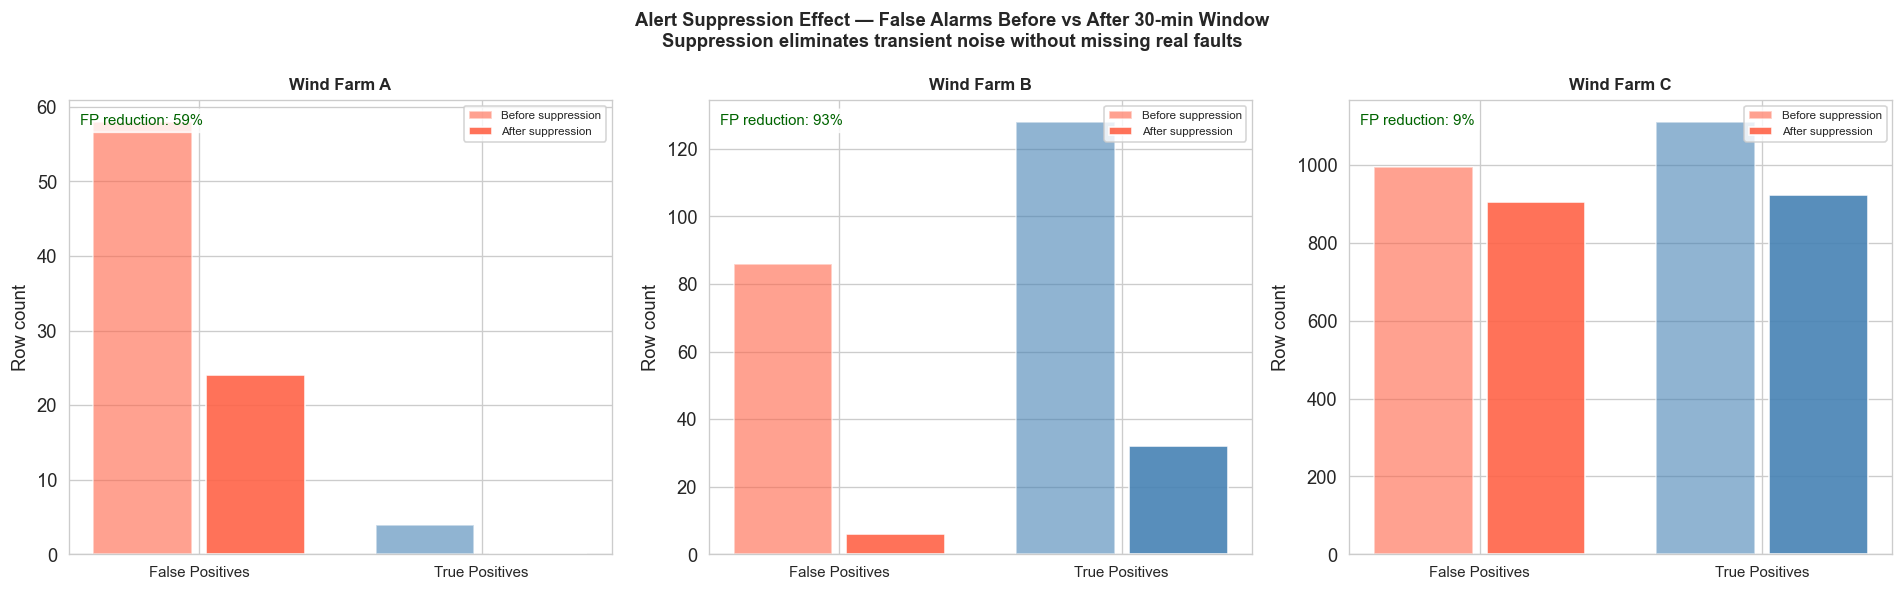

In [12]:
# ── 7.2  False positive reduction from alert suppression ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Alert Suppression Effect — False Alarms Before vs After 30-min Window\n'
             'Suppression eliminates transient noise without missing real faults',
             fontsize=11, fontweight='bold')

for ax, (farm, y) in zip(axes, [
    ('Wind Farm A', y_a), ('Wind Farm B', y_b), ('Wind Farm C', y_c)
]):
    res    = ensemble_data[farm]
    raw    = res['raw']
    sup    = res['suppressed']
    fp_raw = int(raw[y==0].sum())
    fp_sup = int(sup[y==0].sum())
    tp_raw = int(raw[y==1].sum())
    tp_sup = int(sup[y==1].sum())

    categories = ['False Positives', 'True Positives']
    raw_vals   = [fp_raw, tp_raw]
    sup_vals   = [fp_sup, tp_sup]
    x          = np.arange(2)

    ax.bar(x - 0.2, raw_vals, 0.35, label='Before suppression',
           color=['tomato','steelblue'], alpha=0.6)
    ax.bar(x + 0.2, sup_vals, 0.35, label='After suppression',
           color=['tomato','steelblue'], alpha=0.9)
    ax.set_xticks(x); ax.set_xticklabels(categories, fontsize=9)
    ax.set_title(farm, fontsize=10, fontweight='bold')
    ax.set_ylabel('Row count')
    ax.legend(fontsize=7)

    fp_red = (fp_raw - fp_sup) / max(fp_raw, 1) * 100
    ax.text(0.02, 0.97, f'FP reduction: {fp_red:.0f}%',
            transform=ax.transAxes, fontsize=9, va='top',
            color='darkgreen' if fp_red > 0 else 'gray',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

plt.tight_layout()
plt.savefig('fig_2c_alert_suppression.png', bbox_inches='tight')
plt.show()

---
## 8. CARE-Optimised Thresholds

Grid-search over the Isolation Forest threshold to find the operating point that maximises CARE — the competition metric. Demonstrates that F1-optimal ≠ CARE-optimal.

In [13]:
care_opt = {}

for farm, pr_eng, iso_sc in [
    ('Wind Farm A', pred_a_eng, iso_scores['Wind Farm A']),
    ('Wind Farm B', pred_b_eng, iso_scores['Wind Farm B']),
    ('Wind Farm C', pred_c_eng, iso_scores['Wind Farm C']),
]:
    pr     = pr_eng.reset_index(drop=True)
    lo, hi = np.percentile(iso_sc, 1), np.percentile(iso_sc, 99)
    best_thr, best_care = lo, 0.0
    results = []

    for thr in np.linspace(lo, hi, 100):
        c = care_score(pr, iso_sc, thr)
        c['threshold'] = thr
        results.append(c)
        if c['CARE'] > best_care:
            best_care = c['CARE']; best_thr = thr

    base_care = care_score(pr, iso_sc, iso_thrs[farm])['CARE']
    care_opt[farm] = {
        'best_thr'   : best_thr,
        'best_care'  : best_care,
        'base_care'  : base_care,
        'delta'      : round(best_care - base_care, 4),
        'results'    : pd.DataFrame(results),
    }
    print(f'{farm}: baseline={base_care:.4f} → optimised={best_care:.4f} '
          f'(Δ={best_care-base_care:+.4f})')

Wind Farm A: baseline=0.0008 → optimised=0.0009 (Δ=+0.0001)
Wind Farm B: baseline=0.0000 → optimised=0.2586 (Δ=+0.2586)
Wind Farm C: baseline=0.0717 → optimised=0.1698 (Δ=+0.0981)


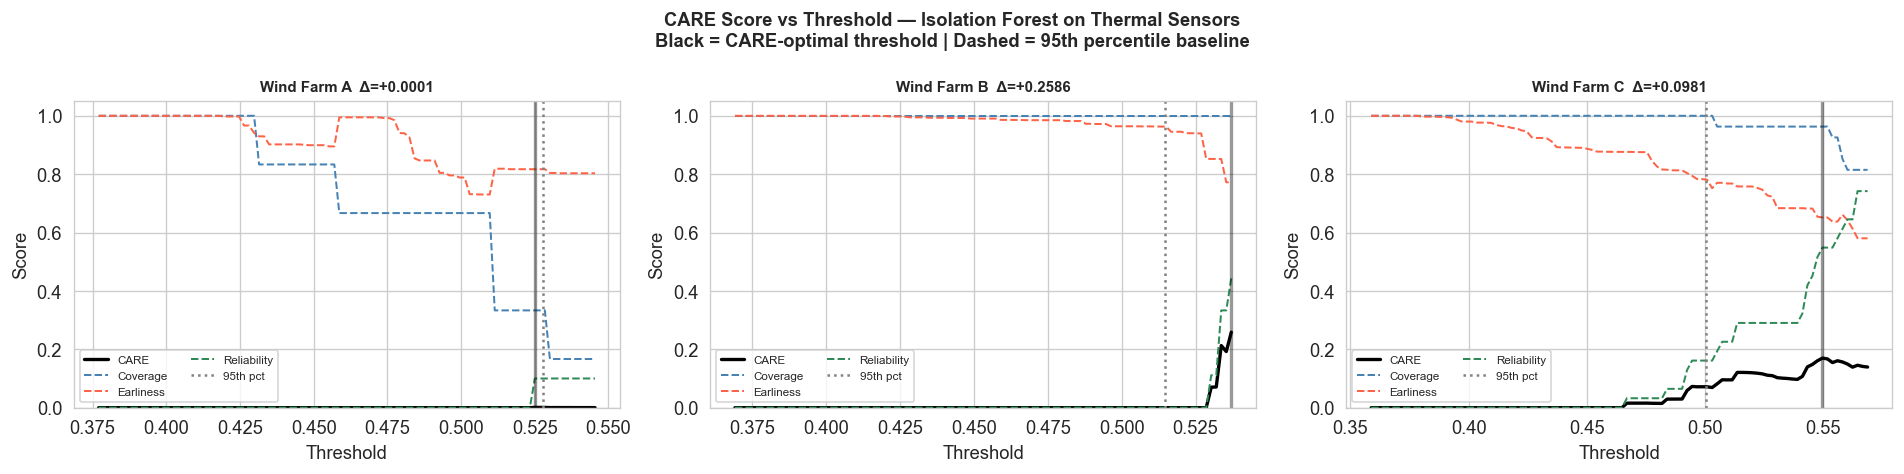

In [14]:
# ── 8.2  CARE curve visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('CARE Score vs Threshold — Isolation Forest on Thermal Sensors\n'
             'Black = CARE-optimal threshold | Dashed = 95th percentile baseline',
             fontsize=11, fontweight='bold')

for ax, (farm, res) in zip(axes, care_opt.items()):
    df = res['results']
    ax.plot(df['threshold'], df['CARE'],        color='black',    lw=2.0, label='CARE')
    ax.plot(df['threshold'], df['Coverage'],    color='steelblue',lw=1.2, linestyle='--', label='Coverage')
    ax.plot(df['threshold'], df['Earliness'],   color='tomato',   lw=1.2, linestyle='--', label='Earliness')
    ax.plot(df['threshold'], df['Reliability'], color='seagreen', lw=1.2, linestyle='--', label='Reliability')
    ax.axvline(iso_thrs[farm],    color='gray',  lw=1.5, linestyle=':', label='95th pct')
    ax.axvline(res['best_thr'],   color='black', lw=2.0, alpha=0.4)
    ax.set_title(f'{farm}  Δ={res["delta"]:+.4f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('fig_2c_care_curves.png', bbox_inches='tight')
plt.show()

---
## 9. Per-Turbine Severity Dashboard

Combines Isolation Forest + T² + rolling-mean into a per-event severity index. The output is a ranked operator risk table — what would appear on a shift-change dashboard.

In [15]:
def compute_severity(pred_eng, iso_sc, iso_thr, t2_sc, t2_thr,
                     rule_fl, farm):
    pr = pred_eng.reset_index(drop=True).copy()
    pr['iso_score'] = iso_sc
    pr['t2_score']  = t2_sc
    pr['iso_flag']  = (pr['iso_score'] > iso_thr).astype(int)
    pr['t2_flag']   = (pr['t2_score']  > t2_thr).astype(int)
    pr['rule_flag'] = rule_fl
    pr['ensemble']  = ((pr['iso_flag'] + pr['t2_flag'] + pr['rule_flag']) >= 2).astype(int)
    pr['sup_flag']  = alert_suppression(pr['ensemble'].values, CONFIRM_STEPS)

    rows = []
    for ev_id in pr['event_id'].unique():
        ev     = pr[pr['event_id']==ev_id]
        label  = ev['event_label'].iloc[0]
        asset  = str(ev['asset_id'].iloc[0]) if 'asset_id' in ev.columns else '?'
        n      = len(ev)

        iso_n  = float(ev['iso_score'].max()) / (iso_sc.max() + 1e-9)
        t2_n   = float(ev['t2_score'].max())  / (t2_sc.max()  + 1e-9)
        sev    = 0.5 * iso_n + 0.5 * t2_n

        flags  = ev['sup_flag'].values
        persist = float(flags.sum()) * 10 / 60
        ff_idx  = ev[ev['sup_flag']==1].index
        early   = 1 - (ff_idx[0] - ev.index[0]) / n if len(ff_idx) else 0.0

        rows.append({'farm':farm,'event_id':ev_id,'asset':str(asset)[-6:],
                     'label':label,'severity':round(sev,4),
                     'persist_hrs':round(persist,1),'earliness':round(float(early),3)})

    return pd.DataFrame(rows).sort_values('severity',ascending=False).reset_index(drop=True)

sev_tables = []
for farm, pr_eng, iso_sc, iso_thr, t2_d, rule_fl in [
    ('Wind Farm A', pred_a_eng, iso_scores['Wind Farm A'], iso_thrs['Wind Farm A'],
     t2_data['Wind Farm A'], rule_flags['Wind Farm A']),
    ('Wind Farm B', pred_b_eng, iso_scores['Wind Farm B'], iso_thrs['Wind Farm B'],
     t2_data['Wind Farm B'], rule_flags['Wind Farm B']),
    ('Wind Farm C', pred_c_eng, iso_scores['Wind Farm C'], iso_thrs['Wind Farm C'],
     t2_data['Wind Farm C'], rule_flags['Wind Farm C']),
]:
    sev = compute_severity(pr_eng, iso_sc, iso_thr,
                           t2_d['scores'], t2_d['thr'], rule_fl, farm)
    sev_tables.append(sev)
    print(f'{farm}: {len(sev)} events scored')

dashboard = pd.concat(sev_tables, ignore_index=True).sort_values(
    'severity', ascending=False).reset_index(drop=True)
dashboard.index += 1

def tier(s):
    if s >= 0.65: return 'CRITICAL'
    if s >= 0.40: return 'WARNING'
    return 'NORMAL'

dashboard['risk_tier'] = dashboard['severity'].apply(tier)

print('\nTHERMAL MONITORING DASHBOARD')
display(dashboard[['farm','event_id','asset','label','severity',
                    'persist_hrs','earliness','risk_tier']]
        .style
        .background_gradient(cmap='YlOrRd', subset=['severity'])
        .format({'severity':'{:.4f}','earliness':'{:.3f}','persist_hrs':'{:.1f}h'})
        .map(lambda v: 'color:red;font-weight:bold' if v=='CRITICAL'
             else ('color:orange' if v=='WARNING' else ''), subset=['risk_tier'])
        .set_caption('Inspect CRITICAL turbines at next shift change'))

print(f'\nCRITICAL: {(dashboard["risk_tier"]=="CRITICAL").sum()}  '
      f'WARNING: {(dashboard["risk_tier"]=="WARNING").sum()}  '
      f'NORMAL: {(dashboard["risk_tier"]=="NORMAL").sum()}')

Wind Farm A: 16 events scored
Wind Farm B: 15 events scored
Wind Farm C: 58 events scored

THERMAL MONITORING DASHBOARD


,farm,event_id,asset,label,severity,persist_hrs,earliness,risk_tier
1,Wind Farm C,36,2,normal,1.0000,120.7h,0.993,CRITICAL
2,Wind Farm A,40,10,anomaly,0.9554,0.0h,0.000,CRITICAL
3,Wind Farm B,27,7,anomaly,0.9536,0.0h,0.000,CRITICAL
4,Wind Farm A,38,13,normal,0.9281,0.0h,0.000,CRITICAL
5,Wind Farm A,69,11,normal,0.8480,0.0h,0.000,CRITICAL
6,Wind Farm C,31,35,anomaly,0.8225,12.5h,0.715,CRITICAL
7,Wind Farm B,7,13,anomaly,0.7506,0.0h,0.000,CRITICAL
8,Wind Farm B,34,14,anomaly,0.7446,0.0h,0.000,CRITICAL
9,Wind Farm A,25,11,normal,0.7212,0.0h,0.000,CRITICAL
10,Wind Farm B,83,2,normal,0.7045,0.0h,0.000,CRITICAL



CRITICAL: 15  WARNING: 49  NORMAL: 25


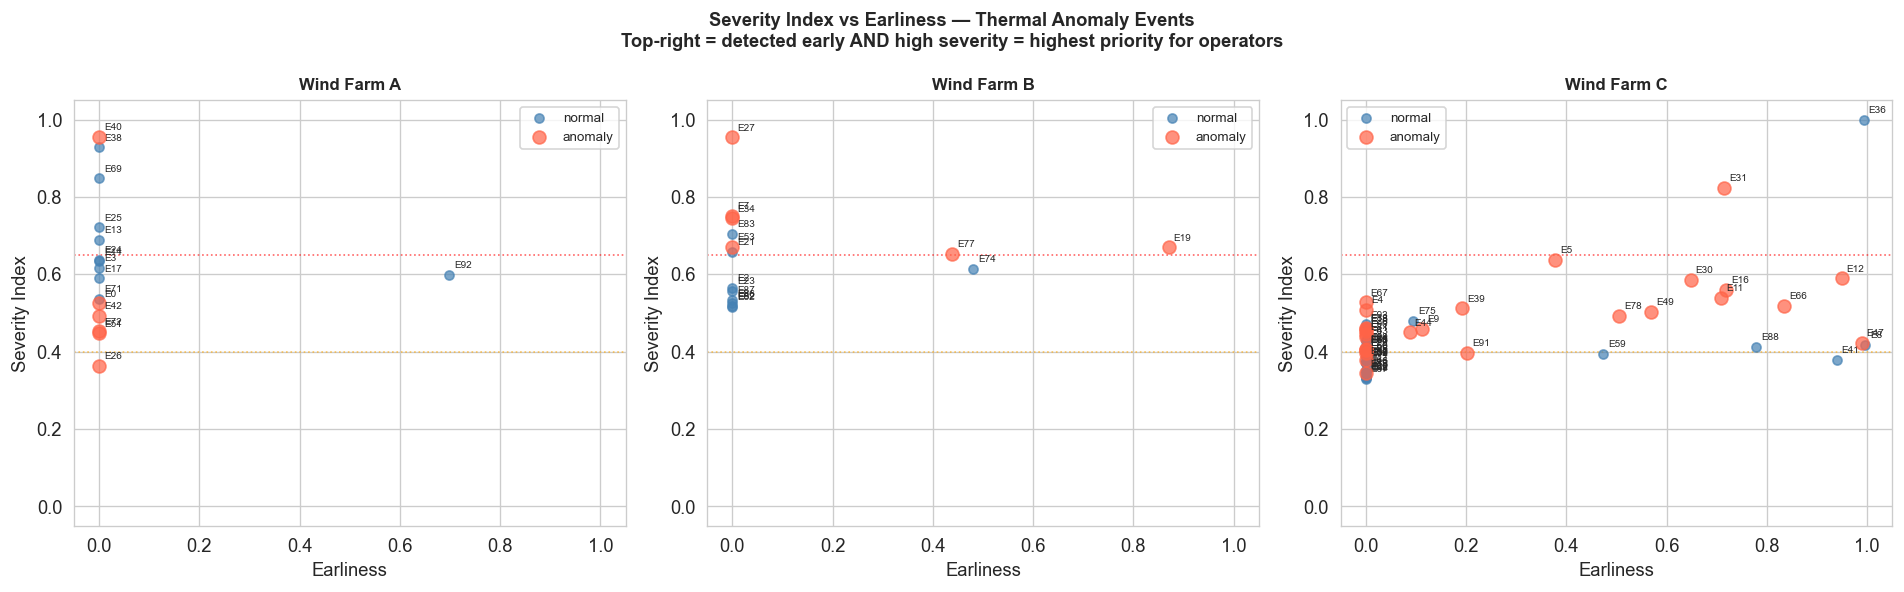

In [16]:
# ── 9.2  Dashboard scatter — severity vs earliness ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Severity Index vs Earliness — Thermal Anomaly Events\n'
             'Top-right = detected early AND high severity = highest priority for operators',
             fontsize=11, fontweight='bold')

for ax, farm in zip(axes, ['Wind Farm A','Wind Farm B','Wind Farm C']):
    sub = dashboard[dashboard['farm']==farm]
    if len(sub) == 0:
        continue
    for label, color, size in [('normal','steelblue',30),('anomaly','tomato',60)]:
        mask = sub['label']==label
        if mask.any():
            ax.scatter(sub[mask]['earliness'], sub[mask]['severity'],
                       c=color, s=size, alpha=0.7, label=label, zorder=3)
            for _, row in sub[mask].iterrows():
                ax.annotate(f"E{row['event_id']}",
                            (row['earliness'], row['severity']),
                            fontsize=6, ha='left', va='bottom',
                            xytext=(3,3), textcoords='offset points')
    ax.axhline(0.65, color='red',    lw=1, linestyle=':', alpha=0.6)
    ax.axhline(0.40, color='orange', lw=1, linestyle=':', alpha=0.6)
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Earliness'); ax.set_ylabel('Severity Index')
    ax.set_title(farm, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_2c_severity_scatter.png', bbox_inches='tight')
plt.show()

---
## 10. Operator Report

Structured summary of all alerts in operator language. This is the deliverable that answers question 2c directly — not just a model output but a concrete operational recommendation.

In [17]:
# ── 10.1  Structured operator alert report ────────────────────────────────────
print('='*70)
print('THERMAL & ELECTRICAL ANOMALY MONITORING — OPERATOR ALERT REPORT')
print('='*70)

print(f'\nReport covers {dashboard["farm"].nunique()} wind farms | '
      f'{dashboard["event_id"].nunique()} prediction events')
print(f'Models: Isolation Forest + Hotelling T² + Rolling-mean Rule (2/3 ensemble)')
print(f'Alert confirmation: {CONFIRM_STEPS} × 10-min steps (30-min persistence required)')

# Critical alerts
critical = dashboard[(dashboard['risk_tier']=='CRITICAL') &
                     (dashboard['label']=='anomaly')]
if len(critical) > 0:
    print(f'\n{"="*50}')
    print(f'  ⚠️  CRITICAL ALERTS ({len(critical)} anomaly events)')
    print(f'{"="*50}')
    for _, row in critical.iterrows():
        print(f'  Farm {row["farm"][-1]} | Event {row["event_id"]} | '
              f'Turbine {row["asset"]} | Severity {row["severity"]:.4f}')
        print(f'    → Persistent flag for {row["persist_hrs"]:.1f}h | '
              f'Detected at {row["earliness"]*100:.0f}% of event elapsed')
        # Find top T² sensor for this event
        farm     = row['farm']
        ev_id    = row['event_id']
        pr_eng   = (pred_a_eng if farm=='Wind Farm A' else
                    pred_b_eng if farm=='Wind Farm B' else pred_c_eng)
        feat     = t2_data[farm]['feat']
        contribs = t2_data[farm]['contribs']
        pr_r     = pr_eng.reset_index(drop=True)
        ev_mask  = pr_r['event_id'] == ev_id
        if ev_mask.any():
            ev_contribs = contribs[ev_mask.values].mean(axis=0)
            top_sensor  = feat[np.argmax(ev_contribs)]
            short       = top_sensor.replace('_avg','').replace('sensor_','sensor ')
            print(f'    → Inspect: {short} (highest T² contribution)')
        print()

print(f'{"="*50}')
print(f'  RECOMMENDED MONITORING STRATEGY')
print(f'{"="*50}')
print('''
  1. TWO-TIER ALERT SYSTEM
     Watch  state: any single model flags → schedule inspection within 72h
     Action state: 2/3 ensemble + 30-min persistence → immediate inspection

  2. SENSOR-LEVEL ATTRIBUTION
     When an alert fires, the T² decomposition identifies the specific
     sensor driving the anomaly. Direct maintenance crews to that component.
     Top sensors by T² contribution are shown in Section 5.

  3. CARE-OPTIMISED THRESHOLDS (Section 8)
     Use CARE-optimal thresholds, not fixed percentiles.
     CARE weights Earliness and Coverage more than F1 — correct for
     predictive maintenance where catching faults early matters most.

  4. PER-TURBINE BASELINES
     Thermal sensor baselines differ across turbines.
     Recompute per-turbine thresholds quarterly using the most recent
     30 days of normal operation data.

  5. CROSS-SENSOR CONFIRMATION
     A single temperature sensor exceeding threshold may be a sensor fault.
     Require at least 2 sensors in the same subsystem to alert simultaneously
     before escalating to maintenance (already implemented via 2/3 ensemble).
''')


# ── Incorporate 2a signal rankings if available ───────────────────────────────
if nb2a_available and signal_stats_2a:
    print(f'{"="*50}')
    print(f'  STRONGEST PRE-FAULT SIGNALS (from Notebook 2a)')
    print(f'{"="*50}')
    for farm, stats in signal_stats_2a.items():
        if len(stats) == 0:
            continue
        print(f'\n  {farm}:')
        for _, row in stats.head(3).iterrows():
            short = row['sensor'].replace('_avg','').replace('sensor_','sensor ')
            direction = 'hotter' if row.get('mean_shift', 0) > 0 else 'cooler'
            print(f'    {short:<35} {row.get("mean_shift",0):+.2f}°C ({direction}) '
                  f'score={row["combined_score"]:.3f}')
    print()

# ── Incorporate 2b AE/VAE scores if available ─────────────────────────────────
if nb2b_available and ae_scores_2b:
    print(f'{"="*50}')
    print(f'  AUTOENCODER SCORES (from Notebook 2b)')
    print(f'{"="*50}')
    for farm in ae_scores_2b:
        ae_sc  = ae_scores_2b[farm]
        ae_thr = ae_thrs_2b.get(farm, np.percentile(ae_sc, 95))
        ae_fl  = (ae_sc > ae_thr).astype(int)
        y_farm = y_a if farm=='Wind Farm A' else (y_b if farm=='Wind Farm B' else y_c)
        print(f'  {farm}: AE P={precision_score(y_farm,ae_fl,zero_division=0):.3f} '
              f'R={recall_score(y_farm,ae_fl,zero_division=0):.3f}')
    print()

# CARE summary
print(f'{"="*50}')
print(f'  CARE SCORES AT OPTIMISED THRESHOLDS')
print(f'{"="*50}')
for farm, res in care_opt.items():
    print(f'  {farm}: {res["best_care"]:.4f} '
          f'(baseline: {res["base_care"]:.4f}, Δ={res["delta"]:+.4f})')

THERMAL & ELECTRICAL ANOMALY MONITORING — OPERATOR ALERT REPORT

Report covers 3 wind farms | 89 prediction events
Models: Isolation Forest + Hotelling T² + Rolling-mean Rule (2/3 ensemble)
Alert confirmation: 3 × 10-min steps (30-min persistence required)

  ⚠️  CRITICAL ALERTS (8 anomaly events)
  Farm A | Event 40 | Turbine 10 | Severity 0.9554
    → Persistent flag for 0.0h | Detected at 0% of event elapsed
    → Inspect: sensor 17_rm6h (highest T² contribution)

  Farm B | Event 27 | Turbine 7 | Severity 0.9536
    → Persistent flag for 0.0h | Detected at 0% of event elapsed
    → Inspect: sensor 33_rm24h (highest T² contribution)

  Farm C | Event 31 | Turbine 35 | Severity 0.8225
    → Persistent flag for 12.5h | Detected at 72% of event elapsed
    → Inspect: sensor 178_rs6h (highest T² contribution)

  Farm B | Event 7 | Turbine 13 | Severity 0.7506
    → Persistent flag for 0.0h | Detected at 0% of event elapsed
    → Inspect: sensor 8_rm24h (highest T² contribution)

  Farm 

In [18]:
# ── EXPORT: Notebook 2c results ───────────────────────────────────────────────
import json, os
os.makedirs('nb2_outputs', exist_ok=True)

out = {'notebook': '2c', 'title': 'Thermal: Practical Monitoring Strategies'}

# Full severity dashboard table
sev_rows = []
if 'dashboard' in dir():
    for _, row in dashboard.iterrows():
        sev_rows.append({
            'farm':        str(row['farm']),
            'event_id':    int(row['event_id']),
            'asset':       str(row['asset']),
            'label':       str(row['label']),
            'severity':    float(row['severity']),
            'persist_hrs': float(row['persist_hrs']),
            'earliness':   float(row['earliness']),
            'risk_tier':   str(row['risk_tier']),
        })
out['severity_dashboard'] = sev_rows

# CARE optimised results
care_rows = []
if 'care_opt' in dir():
    for farm, res in care_opt.items():
        care_rows.append({
            'farm':           farm,
            'baseline_care':  float(res['base_care']),
            'optimised_care': float(res['best_care']),
            'delta':          float(res['delta']),
            'opt_threshold':  round(float(res['best_thr']), 4),
        })
out['care_optimised'] = care_rows

# Ensemble false positive reduction
ensemble_rows = []
if 'ensemble_data' in dir():
    farm_y = {'Wind Farm A': y_a, 'Wind Farm B': y_b, 'Wind Farm C': y_c}
    for farm, res in ensemble_data.items():
        y = farm_y[farm]
        raw = res['raw']; sup = res['suppressed']
        ensemble_rows.append({
            'farm': farm,
            'fp_before': int(raw[y==0].sum()),
            'fp_after':  int(sup[y==0].sum()),
            'tp_before': int(raw[y==1].sum()),
            'tp_after':  int(sup[y==1].sum()),
            'fp_reduction_pct': round((raw[y==0].sum() - sup[y==0].sum()) /
                                       max(raw[y==0].sum(), 1) * 100, 1),
        })
out['ensemble_suppression'] = ensemble_rows

# T2 top sensors per farm (for operator report section on dashboard)
t2_rows = []
if 't2_data' in dir():
    farm_y = {'Wind Farm A': y_a, 'Wind Farm B': y_b, 'Wind Farm C': y_c}
    for farm, data in t2_data.items():
        y      = farm_y[farm]
        preds  = data['preds']
        anom_mask  = (preds == 1) & (y == 1)
        if not anom_mask.any():
            anom_mask = preds == 1
        mean_c = data['contribs'][anom_mask].mean(axis=0)
        top5_idx = np.argsort(mean_c)[::-1][:5]
        for rank, idx in enumerate(top5_idx):
            feat_name = data['feat'][idx]
            t2_rows.append({
                'farm': farm,
                'rank': rank + 1,
                'feature': feat_name,
                'feature_short': feat_name.replace('_avg','').replace('sensor_','sensor '),
                'contribution': round(float(mean_c[idx]), 6),
            })
out['t2_sensor_attribution'] = t2_rows

with open('nb2_outputs/nb2c_results.json', 'w') as f:
    json.dump(out, f, indent=2)
print(f'Saved nb2c_results.json')
print(f'  {len(sev_rows)} severity rows')
print(f'  {len(care_rows)} CARE rows')
print(f'  {len(ensemble_rows)} ensemble rows')
print(f'  {len(t2_rows)} T2 attribution rows')

Saved nb2c_results.json
  89 severity rows
  3 CARE rows
  3 ensemble rows
  15 T2 attribution rows
